In [1]:
import pyclara
import sdds
import matplotlib.pyplot as plt
import numpy as np

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

### Plot XSuite optical functions

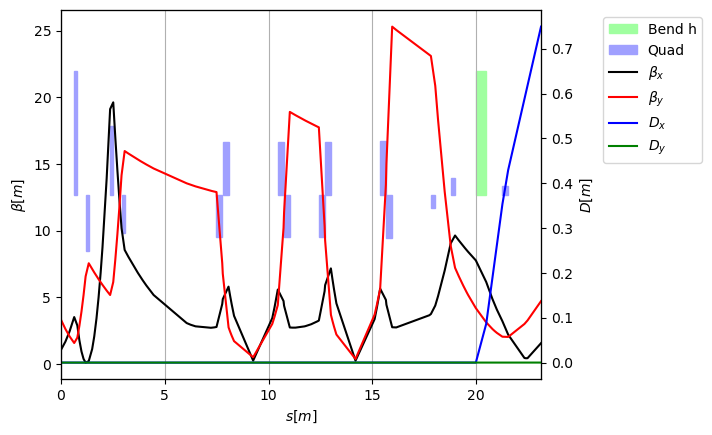

In [3]:
xsuite_twiss['xtrack_twiss'].plot()

### Compare XSuite with Elegant

Difference in spectrometer bend is due to edge effects which are *on* in both codes

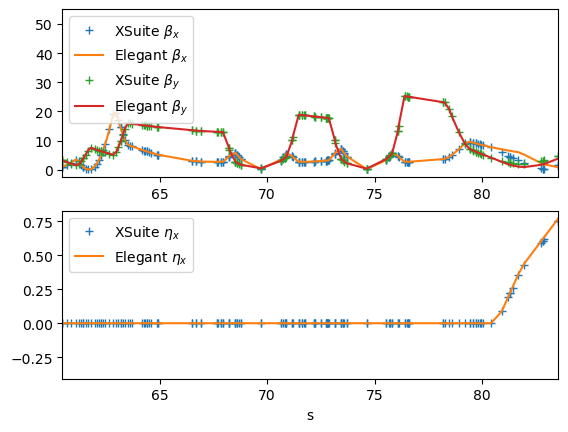

In [4]:
xtrack_twiss =xsuite_twiss['xtrack_twiss']
elegant_twi = sdds.load("../Run/FEBE.twi")

elegant_s = np.array(elegant_twi.getColumnValueList('s'))
elegant_betax = np.array(elegant_twi.getColumnValueList('betax'))
elegant_betay = np.array(elegant_twi.getColumnValueList('betay'))
elegant_etax =  np.array(elegant_twi.getColumnValueList('etax'))

s0 = xsuite_twiss['env'].lines['FEBE'].particle_ref.s

plt.subplot(2,1,1)
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['betx'],"+", label="XSuite $\\beta_x$")
plt.plot(elegant_s, elegant_betax,"-", label="Elegant $\\beta_x$")
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['bety'],"+", label="XSuite $\\beta_y$")
plt.plot(elegant_s, elegant_betay,"-", label="Elegant $\\beta_y$")
plt.xlim(s0,elegant_s.max())
plt.legend()

plt.subplot(2,1,2)
plt.plot(xtrack_twiss['s']+s0, xtrack_twiss['dx'],"+", label="XSuite $\\eta_x$")
plt.plot(elegant_s, elegant_etax,"-", label="Elegant $\\eta_x$")
plt.xlim(s0,elegant_s.max())
plt.legend()

plt.xlabel("s");

### XSuite tracking

In [5]:
xsuite_track = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_ps="../Run/CLA-FEA-SIM-DIP-04-END.SDDS")